In [ ]:
# === SETUP ===
!pip install -q tensorflow opencv-python-headless matplotlib pyyaml

In [ ]:
import os
import pandas as pd
import zipfile
import shutil
import yaml
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

Loading dataset

In [ ]:
# STEP 1: Load dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Path to your dataset inside Google Drive
dataset_dir = '/content/drive/MyDrive/Tomato_Dataset'

# Check contents
os.listdir(dataset_dir)

['data.yaml',
 'README.roboflow.txt',
 'README.dataset.txt',
 'test',
 'valid',
 'train',
 'tomato_multilabel_dataset.csv']

Converting yolo to multi-label

In [ ]:
# Class names from your data.yaml
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']
num_classes = len(class_names)

In [ ]:

# Helps to process one split (train/valid/test)
def process_split(split):
    image_dir = os.path.join(dataset_dir, split, 'images')
    label_dir = os.path.join(dataset_dir, split, 'labels')
    data = []

    for filename in os.listdir(label_dir):
        if filename.endswith('.txt'):
            label_path = os.path.join(label_dir, filename)
            image_filename = filename.replace('.txt', '.jpg')  # assuming .jpg images
            image_path = os.path.join(image_dir, image_filename)

            # Initialize a zero label vector
            label_vector = [0] * num_classes

            # Read YOLO annotations
            with open(label_path, 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    label_vector[class_id] = 1  # multi-label

            data.append([image_path] + label_vector)

    return pd.DataFrame(data, columns=['image_path'] + class_names)


# Process all splits
df_train = process_split('train')
df_valid = process_split('valid')
df_test = process_split('test')

#  Merge all into one CSV (or keep separate)
df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)

# Save to CSV
output_csv_path = os.path.join(dataset_dir, 'tomato_multilabel_dataset.csv')
df_all.to_csv(output_csv_path, index=False)

print(f"CSV saved to: {output_csv_path}")

CSV saved to: /content/drive/MyDrive/Tomato_Dataset/tomato_multilabel_dataset.csv


In [ ]:
import os
import pandas as pd
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch

# Step 1: Clear GPU memory
import gc
torch.cuda.empty_cache()
gc.collect()

# Step 2: Read the cleaned CSV
csv_path = os.path.join(dataset_dir, 'tomato_multilabel_dataset.csv')
df = pd.read_csv(csv_path)

# Step 3: Remove broken image paths
df = df[df['image_path'].apply(lambda x: Path(x).exists())].reset_index(drop=True)

# Step 4: Split the dataset
df_train = df[df['image_path'].str.contains('/train/')]
df_valid = df[df['image_path'].str.contains('/valid/')]
df_test  = df[df['image_path'].str.contains('/test/')]

# Step 5: Define image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Step 6: Define custom dataset class
class MultiLabelTomatoDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        self.labels = dataframe.iloc[:, 1:].values.astype('float32')

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_path = self.df.iloc[idx, 0]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx])
        return image, label

# Step 7: DataLoaders (Batch size = 8)
train_loader = DataLoader(MultiLabelTomatoDataset(df_train, transform=transform), batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(MultiLabelTomatoDataset(df_valid, transform=transform), batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(MultiLabelTomatoDataset(df_test,  transform=transform), batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(df_train)} | Valid: {len(df_valid)} | Test: {len(df_test)} — all paths verified ")

Train: 645 | Valid: 61 | Test: 31 — all paths verified 


Loading efficientnet

In [ ]:
import torch
import torch.nn as nn
import timm

# Device config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load EfficientNetV2
model = timm.create_model("efficientnetv2_rw_m", pretrained=True)
model.reset_classifier(num_classes=7)  # 7 output neurons for 7 labels
model = model.to(device)

# Define loss & optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("Model ready with EfficientNetV2 + 7 output neurons (multi-label)")


Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/214M [00:00<?, ?B/s]

Model ready with EfficientNetV2 + 7 output neurons (multi-label)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import os


# Folder to save best model
os.makedirs("saved_models", exist_ok=True)

# Evaluation function
def evaluate(model, dataloader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return acc, prec, rec, f1

# Training loop
def train(model, train_loader, valid_loader, criterion, optimizer, num_epochs=20):
    best_f1 = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        acc, prec, rec, f1 = evaluate(model, valid_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] — Loss: {running_loss:.4f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "saved_models/best_efficientnetv2_multilabel.pth")
            print(" ✅ Best model saved!")

# Train the model
train(model, train_loader, valid_loader, criterion, optimizer, num_epochs=20)


Epoch [1/20] — Loss: 12.7058 | Acc: 0.4590 | Prec: 0.5723 | Recall: 0.4107 | F1: 0.4583
 ✅ Best model saved!
Epoch [2/20] — Loss: 8.3217 | Acc: 0.6721 | Prec: 0.7475 | Recall: 0.6187 | F1: 0.6711
 ✅ Best model saved!
Epoch [3/20] — Loss: 4.8292 | Acc: 0.7705 | Prec: 0.8333 | Recall: 0.6812 | F1: 0.7295
 ✅ Best model saved!
Epoch [4/20] — Loss: 2.7858 | Acc: 0.7869 | Prec: 0.6904 | Recall: 0.6362 | F1: 0.6602
Epoch [5/20] — Loss: 1.7314 | Acc: 0.8197 | Prec: 0.8809 | Recall: 0.7481 | F1: 0.7877
 ✅ Best model saved!
Epoch [6/20] — Loss: 1.4431 | Acc: 0.8525 | Prec: 0.9051 | Recall: 0.7477 | F1: 0.7989
 ✅ Best model saved!
Epoch [7/20] — Loss: 1.0097 | Acc: 0.8525 | Prec: 0.9186 | Recall: 0.7984 | F1: 0.8337
 ✅ Best model saved!
Epoch [8/20] — Loss: 0.7725 | Acc: 0.8689 | Prec: 0.9287 | Recall: 0.8003 | F1: 0.8370
 ✅ Best model saved!
Epoch [9/20] — Loss: 0.5931 | Acc: 0.8689 | Prec: 0.9283 | Recall: 0.7935 | F1: 0.8332
Epoch [10/20] — Loss: 0.5309 | Acc: 0.8361 | Prec: 0.8472 | Recall: 0

Validation

In [ ]:
from sklearn.metrics import classification_report

# Load best saved model
model.load_state_dict(torch.load("saved_models/best_efficientnetv2_multilabel.pth"))
model.eval()

# Evaluate on test set
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification Report (per class)
target_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']
print("Classification Report on Test Set:\n")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

Classification Report on Test Set:

                precision    recall  f1-score   support

Bacterial Spot       1.00      1.00      1.00         2
  Early_Blight       0.88      1.00      0.94        15
       Healthy       1.00      1.00      1.00         7
   Late_blight       1.00      1.00      1.00         9
     Leaf Mold       1.00      0.75      0.86         4
   Target_Spot       0.67      1.00      0.80         2
    black spot       0.89      0.89      0.89         9

     micro avg       0.92      0.96      0.94        48
     macro avg       0.92      0.95      0.93        48
  weighted avg       0.93      0.96      0.94        48
   samples avg       0.96      0.97      0.96        48



In [ ]:
# === Evaluate Pre-trained Model on Test Set ===
model = timm.create_model("efficientnetv2_rw_m", pretrained=True)
model.reset_classifier(num_classes=7)
model.load_state_dict(torch.load("saved_models/best_efficientnetv2_multilabel.pth"))
model = model.to(device)
model.eval()

acc_pre, prec_pre, rec_pre, f1_pre = evaluate(model, test_loader)

print("\n📊 Pre-trained Model Test Set Performance:")
print(f"Accuracy: {acc_pre:.4f}")
print(f"Precision (macro): {prec_pre:.4f}")
print(f"Recall (macro): {rec_pre:.4f}")
print(f"F1-score (macro): {f1_pre:.4f}")



📊 Pre-trained Model Test Set Performance:
Accuracy: 0.9032
Precision (macro): 0.9197
Recall (macro): 0.9484
F1-score (macro): 0.9262


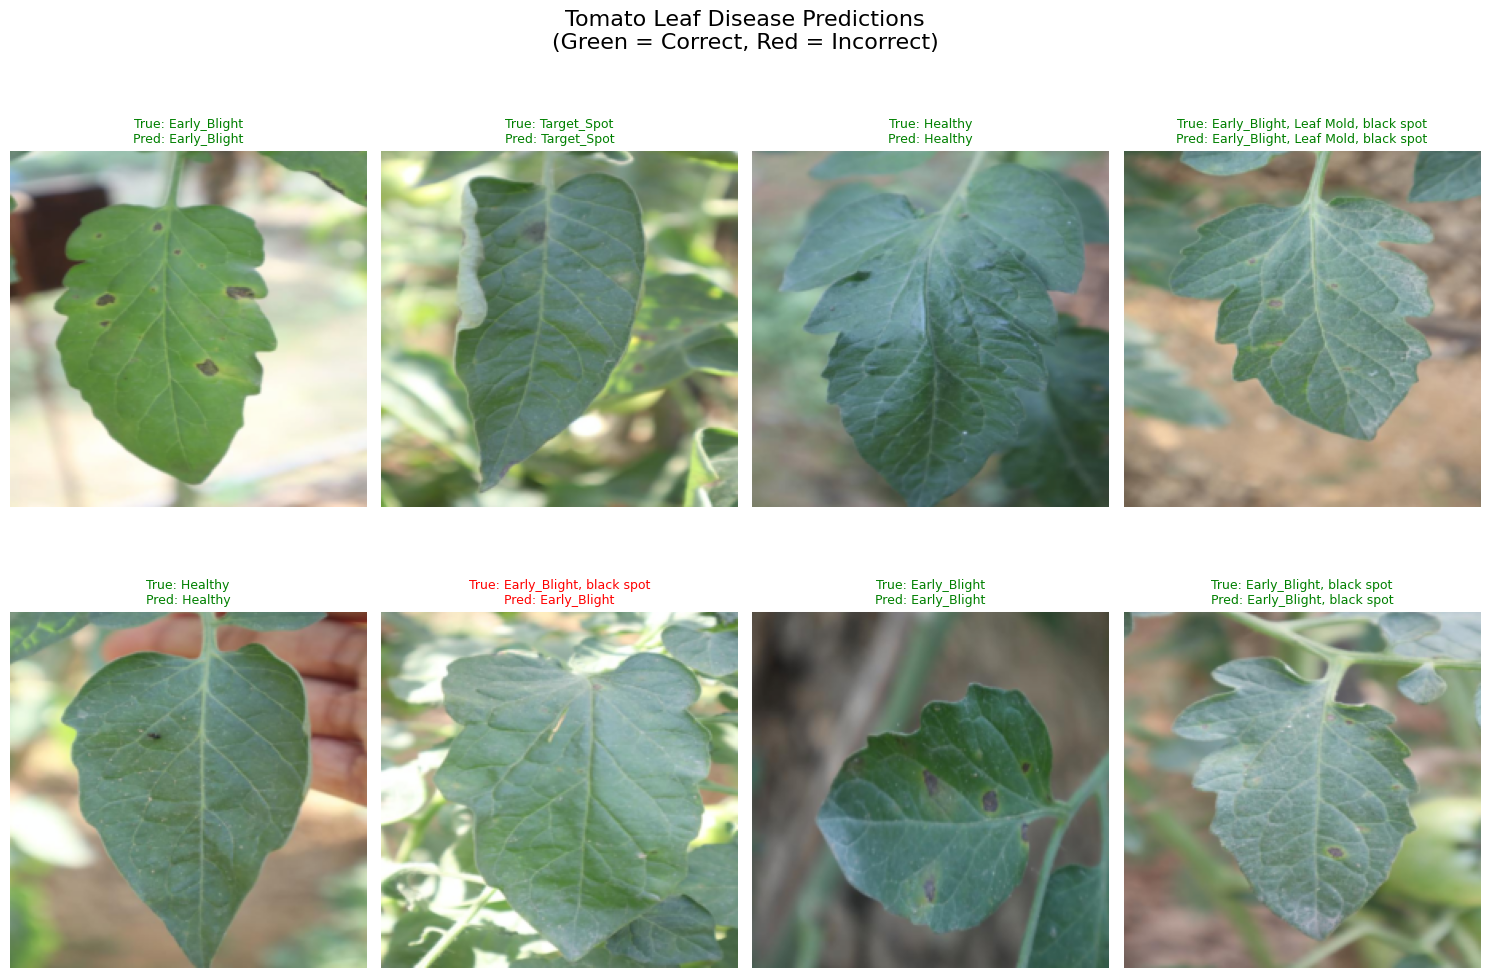

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Disease class names
class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']

# Pick a few samples from test set
samples_to_show = 8
model.eval()

images_shown = 0

plt.figure(figsize=(15, 10))

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float().cpu()

        for i in range(images.size(0)):
            if images_shown >= samples_to_show:
                break

            image = images[i].permute(1, 2, 0).numpy()
            image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
            image = np.clip(image, 0, 1)

            true_labels = [class_names[j] for j in range(len(class_names)) if labels[i][j] == 1]
            pred_labels = [class_names[j] for j in range(len(class_names)) if preds[i][j] == 1]

            plt.subplot(2, 4, images_shown + 1)
            plt.imshow(image)
            plt.axis('off')
            plt.title(f"True: {', '.join(true_labels)}\nPred: {', '.join(pred_labels)}",
                      fontsize=9, color='green' if true_labels == pred_labels else 'red')

            images_shown += 1

        if images_shown >= samples_to_show:
            break

plt.tight_layout()
plt.suptitle("Tomato Leaf Disease Predictions\n(Green = Correct, Red = Incorrect)", fontsize=16, y=1.05)
plt.show()

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix

cm = multilabel_confusion_matrix(y_true, y_pred)
for i, class_name in enumerate(class_names):
    print(f"Confusion Matrix for {class_name}:\n{cm[i]}\n")


Confusion Matrix for Bacterial Spot:
[[29  0]
 [ 0  2]]

Confusion Matrix for Early_Blight:
[[14  2]
 [ 0 15]]

Confusion Matrix for Healthy:
[[24  0]
 [ 0  7]]

Confusion Matrix for Late_blight:
[[22  0]
 [ 0  9]]

Confusion Matrix for Leaf Mold:
[[27  0]
 [ 1  3]]

Confusion Matrix for Target_Spot:
[[28  1]
 [ 0  2]]

Confusion Matrix for black spot:
[[21  1]
 [ 1  8]]



Genetic Agorithm

In [ ]:
# === Genetic Algorithm Optimization ===

import random
import copy
import torch
import torch.nn as nn
import timm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Define hyperparameter search space
search_space = {
    'lr': [1e-5, 1e-4, 5e-4],
    'dropout': [0.1, 0.3, 0.5],
    'weight_decay': [0.0, 1e-5],
    'batch_size': [16, 32]
}

# Ensure device is defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create model with dynamic dropout
def create_model(dropout):
    model = timm.create_model("efficientnetv2_rw_m", pretrained=True)
    model.classifier = torch.nn.Sequential(
        torch.nn.Dropout(dropout),
        torch.nn.Linear(model.classifier.in_features, 7) # Assuming 7 classes
    )
    return model.to(device)

# --- Start of correct evaluate function definition ---
# Evaluation function (used by GA to get fitness score)
def evaluate(model, dataloader, threshold=0.5):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > threshold).float()

            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return acc, prec, rec, f1
# --- End of correct evaluate function definition ---


# Train and evaluate one individual
def train_and_evaluate(hparams, epochs=3):
    # Ensure MultiLabelTomatoDataset and transform are accessible
    # Assuming they are defined in previous cells
    # If not, copy their definitions here as well
    batch_size = hparams['batch_size']
    train_loader = DataLoader(MultiLabelTomatoDataset(df_train, transform=transform), batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(MultiLabelTomatoDataset(df_valid, transform=transform), batch_size=batch_size, shuffle=False, num_workers=2)

    model = create_model(hparams['dropout'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=hparams['lr'], weight_decay=hparams['weight_decay'])
    criterion = torch.nn.BCEWithLogitsLoss() # Ensure criterion is defined

    for epoch in range(epochs):
        model.train()
        # Use tqdm for progress bar if available and desired
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Evaluate on validation set after each epoch (optional, but good for tracking)
        # acc, prec, rec, f1_val = evaluate(model, val_loader)
        # print(f"  Epoch {epoch+1} Validation F1: {f1_val:.4f}")

    # Final evaluation after all epochs for the individual's score
    _, _, _, f1 = evaluate(model, val_loader) # This will now unpack correctly
    return f1, model

# GA operations
def random_individual():
    return {key: random.choice(values) for key, values in search_space.items()}

def mutate(individual):
    key = random.choice(list(individual.keys()))
    individual[key] = random.choice(search_space[key])
    return individual

def crossover(parent1, parent2):
    return {k: random.choice([parent1[k], parent2[k]]) for k in parent1}

# GA main loop
def genetic_algorithm(pop_size=6, generations=5, epochs=3):
    population = [random_individual() for _ in range(pop_size)]
    best_model = None
    best_score = 0.0
    best_params = None

    for gen in range(generations):
        print(f"\n--- Generation {gen+1} ---")
        scores = []

        for ind in population:
            # The error happens here because evaluate doesn't return 4 values
            f1, model = train_and_evaluate(ind, epochs)
            print(f"Evaluated {ind} => F1: {f1:.4f}")
            scores.append((f1, ind, model))
            if f1 > best_score:
                best_score = f1
                best_model = copy.deepcopy(model)
                best_params = ind

        scores.sort(reverse=True, key=lambda x: x[0])
        # Select top 2 parents for crossover
        parents = [x[1] for x in scores[:2]]

        new_population = parents[:]
        while len(new_population) < pop_size:
            # Perform crossover - select parents randomly from the top 2
            child = crossover(random.choice(parents), random.choice(parents))
            # Perform mutation
            if random.random() < 0.3: # Mutation rate
                child = mutate(child)
            new_population.append(child)

        population = new_population

    print(f"\nBest Hyperparameters: {best_params}")
    print(f"Best Validation F1-score: {best_score:.4f}")
    # Ensure 'saved_models' directory exists
    import os
    os.makedirs("saved_models", exist_ok=True)
    torch.save(best_model.state_dict(), "saved_models/best_efficientnetv2_ga.pth")
    return best_params, best_model

# Run GA
best_params, best_model = genetic_algorithm()


--- Generation 1 ---
Evaluated {'lr': 0.0001, 'dropout': 0.1, 'weight_decay': 1e-05, 'batch_size': 16} => F1: 0.7852
Evaluated {'lr': 0.0001, 'dropout': 0.1, 'weight_decay': 1e-05, 'batch_size': 16} => F1: 0.7354
Evaluated {'lr': 1e-05, 'dropout': 0.5, 'weight_decay': 1e-05, 'batch_size': 32} => F1: 0.3590
Evaluated {'lr': 0.0005, 'dropout': 0.5, 'weight_decay': 1e-05, 'batch_size': 16} => F1: 0.7834
Evaluated {'lr': 0.0005, 'dropout': 0.1, 'weight_decay': 0.0, 'batch_size': 32} => F1: 0.8947
Evaluated {'lr': 0.0005, 'dropout': 0.3, 'weight_decay': 0.0, 'batch_size': 16} => F1: 0.9005

--- Generation 2 ---
Evaluated {'lr': 0.0005, 'dropout': 0.3, 'weight_decay': 0.0, 'batch_size': 16} => F1: 0.8536
Evaluated {'lr': 0.0005, 'dropout': 0.1, 'weight_decay': 0.0, 'batch_size': 32} => F1: 0.8407
Evaluated {'lr': 0.0005, 'dropout': 0.1, 'weight_decay': 0.0, 'batch_size': 16} => F1: 0.8663
Evaluated {'lr': 0.0005, 'dropout': 0.1, 'weight_decay': 0.0, 'batch_size': 32} => F1: 0.8411
Evaluated


📋 Classification Report (Macro Avg):
                precision    recall  f1-score   support

Bacterial Spot       1.00      1.00      1.00         2
  Early_Blight       1.00      1.00      1.00        15
       Healthy       1.00      1.00      1.00         7
   Late_blight       1.00      1.00      1.00         9
     Leaf Mold       0.75      0.75      0.75         4
   Target_Spot       0.67      1.00      0.80         2
    black spot       1.00      0.89      0.94         9

     micro avg       0.96      0.96      0.96        48
     macro avg       0.92      0.95      0.93        48
  weighted avg       0.97      0.96      0.96        48
   samples avg       0.98      0.97      0.97        48



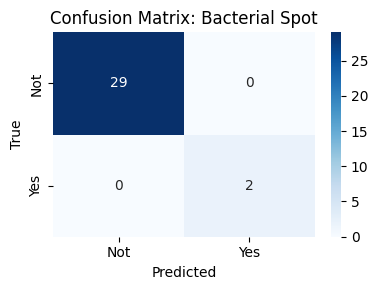

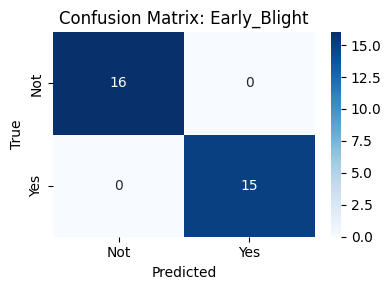

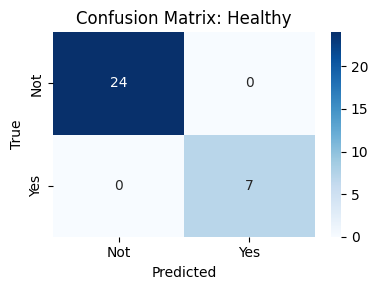

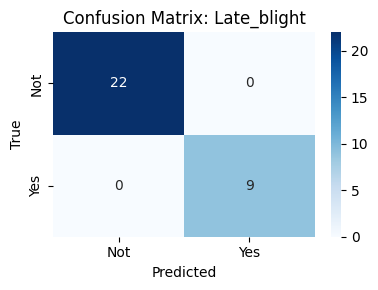

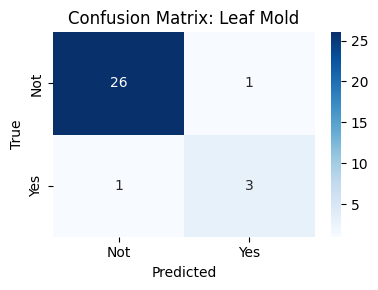

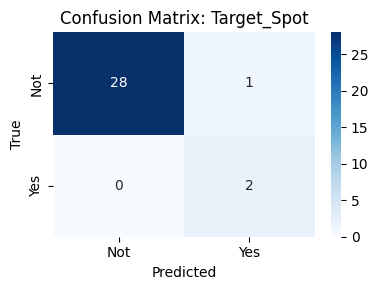

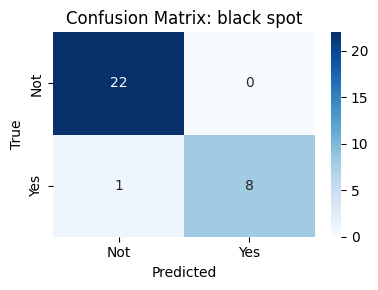

In [ ]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the best GA model again (just in case)
model = create_model(best_params['dropout'])
model.load_state_dict(torch.load("saved_models/best_efficientnetv2_ga.pth"))
model.to(device)
model.eval()

# 2. Predict on test set
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 3. Classification Report
print("\n📋 Classification Report (Macro Avg):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# 4. Confusion Matrix per Class
conf_matrices = multilabel_confusion_matrix(y_true, y_pred)

for i, class_name in enumerate(class_names):
    cm = conf_matrices[i]
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Not", "Yes"], yticklabels=["Not", "Yes"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix: {class_name}")
    plt.tight_layout()
    plt.show()

Bootstrap 95 % Confidence Intervals for Accuracy, Precision, Recall, F1

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils import resample
import numpy as np

# y_true and y_pred already exist
n_iterations = 2000          # more iterations → tighter CI but slower
rng = np.random.RandomState(42)

scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for _ in range(n_iterations):
    idx = resample(np.arange(len(y_true)), random_state=rng)   # bootstrap indices
    yt_bs = y_true[idx]
    yp_bs = y_pred[idx]

    scores["acc"].append(accuracy_score(yt_bs, yp_bs))
    scores["prec"].append(precision_score(yt_bs, yp_bs, average="macro", zero_division=0))
    scores["rec"].append(recall_score(yt_bs, yp_bs, average="macro", zero_division=0))
    scores["f1"].append(f1_score(yt_bs, yp_bs, average="macro", zero_division=0))

for k, v in scores.items():
    ci_low, ci_high = np.percentile(v, [2.5, 97.5])
    mean_val = np.mean(v)
    print(f"{k.upper():6s}: {mean_val:.4f}  (95% CI{ci_low:.4f} – {ci_high:.4f})")

ACC   : 0.8708  (95% CI0.7419 – 0.9677)
PREC  : 0.8920  (95% CI0.7500 – 1.0000)
REC   : 0.9104  (95% CI0.7321 – 1.0000)
F1    : 0.8906  (95% CI0.7476 – 0.9841)


ROC & Precision–Recall Curves per class

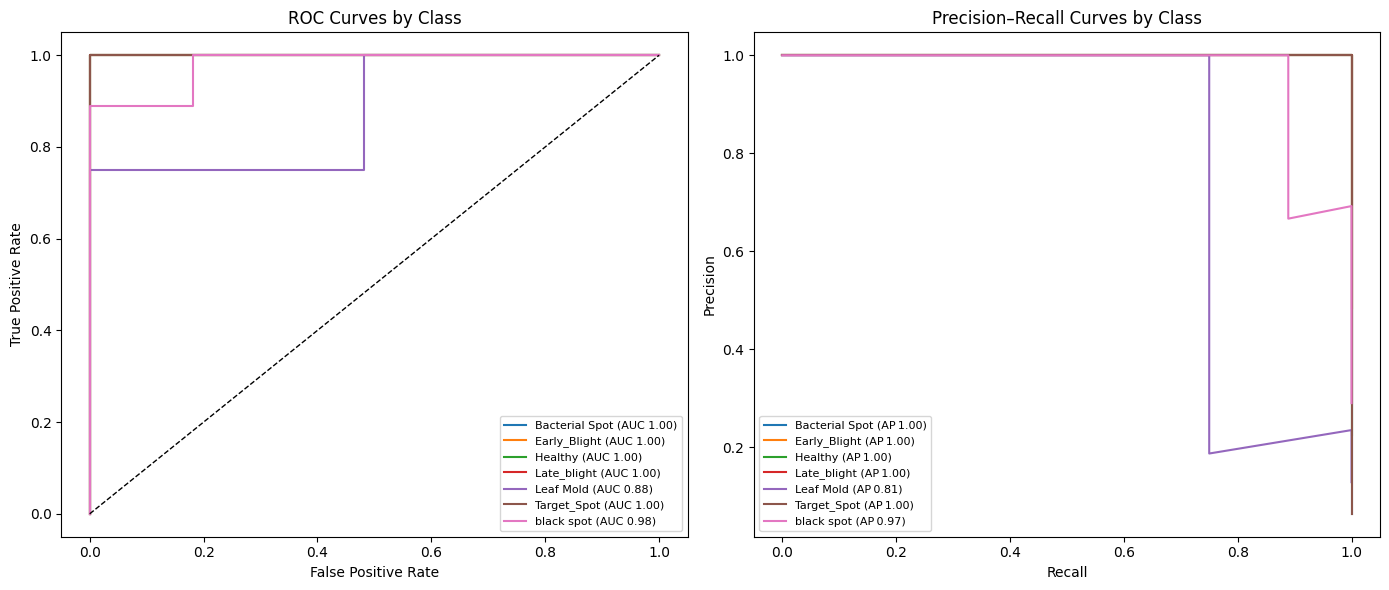

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np # Ensure numpy is imported here

class_names = ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']

n_classes = len(class_names)
plt.figure(figsize=(14, 6))

# Assume y_true and probs are available from previous cells
# y_true should already be a numpy array.
# probs was calculated from the model output and is likely on the GPU.

# Move probs to CPU before using with scikit-learn
probs_cpu = probs.cpu().numpy()

# ---- ROC curves ----
plt.subplot(1, 2, 1)
for i in range(n_classes):
    # Use probs_cpu for scikit-learn functions
    fpr, tpr, _ = roc_curve(y_true[:, i], probs_cpu[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.5, label=f"{class_names[i]} (AUC {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Class")
plt.legend(fontsize=8)

# ---- Precision‑Recall curves ----
plt.subplot(1, 2, 2)
for i in range(n_classes):
    # Use probs_cpu for scikit-learn functions
    prec, rec, _ = precision_recall_curve(y_true[:, i], probs_cpu[:, i])
    ap = average_precision_score(y_true[:, i], probs_cpu[:, i])
    plt.plot(rec, prec, lw=1.5, label=f"{class_names[i]} (AP {ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves by Class")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Load best model with GA-selected dropout
model = create_model(best_params['dropout'])
model.load_state_dict(torch.load("saved_models/best_efficientnetv2_ga.pth"))
model.to(device)
model.eval()

# Evaluate on test set
acc, prec, rec, f1 = evaluate(model, test_loader)
print(f"\n📊 Test Set Evaluation:\nAccuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1:.4f}")


📊 Test Set Evaluation:
Accuracy: 0.8710 | Precision: 0.9167 | Recall: 0.9484 | F1-score: 0.9273


In [ ]:
from google.colab import files
files.download("saved_models/best_efficientnetv2_ga.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>